In [ ]:
!pip install torch kornia kornia-rs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 128.7 MB/s eta 0:00:00


In [ ]:
!pip install torch
!pip install git+https://github.com/cvg/LightGlue.git

  Cloning https://github.com/cvg/LightGlue.git to /tmp/pip-req-build-p3xqw7tt
  Running command git clone --filter=blob:none --quiet https://github.com/cvg/LightGlue.git /tmp/pip-req-build-p3xqw7tt
  Resolved https://github.com/cvg/LightGlue.git to commit eb42fee2d71449efb0aa5c10549752b5d75384d8
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for lightglue: filename=lightglue-0.0-py3-none-any.whl size=40248 sha256=0a49839f9d4f53c0066a648d62e24f4f19949f794a78ab1686ae005140f20950
  Stored in directory: /tmp/pip-ephem-wheel-cache-rvrgobgp/wheels/dd/58/9b/b88be0e64ece5eb28a6b6ee5145e2ab303d23543f943142f0a
Successfully built lightglue


Using device: cuda
Downloading: "https://github.com/cvg/LightGlue/releases/download/v0.1_arxiv/superpoint_v1.pth" to /root/.cache/torch/hub/checkpoints/superpoint_v1.pth


100%|██████████| 4.96M/4.96M [00:00<00:00, 148MB/s]

Downloading: "https://raw.githubusercontent.com/cvlab-epfl/disk/master/depth-save.pth" to /root/.cache/torch/hub/checkpoints/depth-save.pth



100%|██████████| 4.17M/4.17M [00:00<00:00, 132MB/s]


Downloading: "https://github.com/Shiaoming/ALIKED/raw/main/models/aliked-n16.pth" to /root/.cache/torch/hub/checkpoints/aliked-n16.pth


100%|██████████| 2.61M/2.61M [00:00<00:00, 96.6MB/s]


Downloading: "https://github.com/cvg/LightGlue/releases/download/v0.1_arxiv/superpoint_lightglue.pth" to /root/.cache/torch/hub/checkpoints/superpoint_lightglue_v0-1_arxiv.pth


100%|██████████| 45.3M/45.3M [00:00<00:00, 302MB/s]


SuperPoint: 2048 & 2048 keypoints, 622 matches, 2.071s


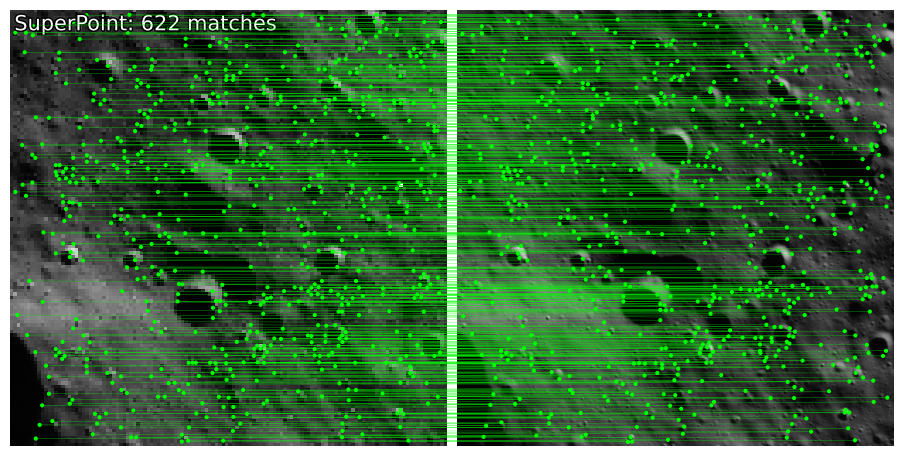

Downloading: "https://github.com/cvg/LightGlue/releases/download/v0.1_arxiv/disk_lightglue.pth" to /root/.cache/torch/hub/checkpoints/disk_lightglue_v0-1_arxiv.pth


100%|██████████| 45.4M/45.4M [00:00<00:00, 109MB/s]


DISK: 2048 & 2048 keypoints, 192 matches, 0.655s


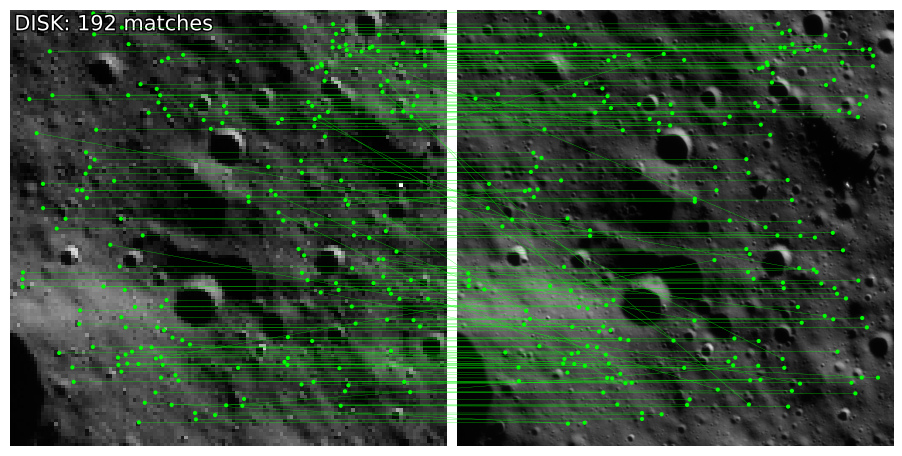

Downloading: "https://github.com/cvg/LightGlue/releases/download/v0.1_arxiv/aliked_lightglue.pth" to /root/.cache/torch/hub/checkpoints/aliked_lightglue_v0-1_arxiv.pth


100%|██████████| 45.4M/45.4M [00:00<00:00, 65.0MB/s]


ALIKED: 628 & 2048 keypoints, 438 matches, 0.430s


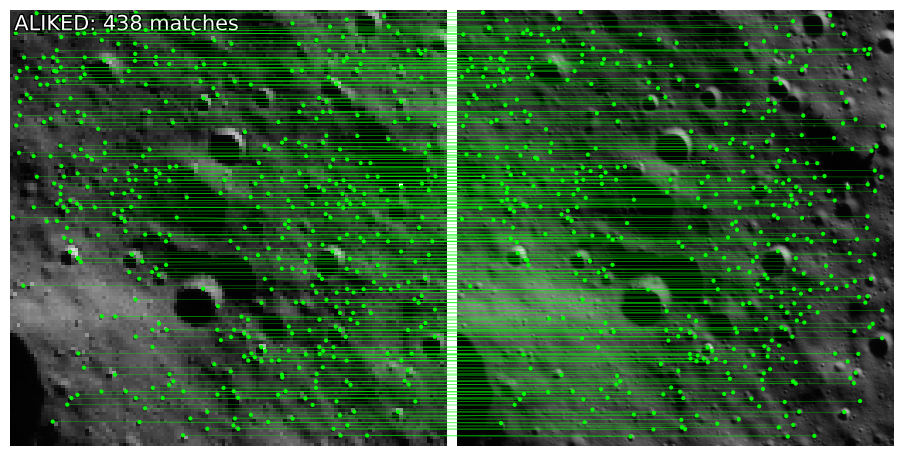


Algorithm   KP img1   KP img2   Matches   Time(s)   
SuperPoint  2048      2048      622       2.071     
DISK        2048      2048      192       0.655     
ALIKED      628       2048      438       0.43      


In [ ]:
"""
6.5 Feature detection — learned methods: SuperPoint, DISK, ALIKED.

Uses the official LightGlue package (from the paper authors), which bundles
pretrained SuperPoint/DISK/ALIKED extractors + a fast learned matcher.
Weights auto-download on first run — no manual GitHub weight-hunting needed.

HOW TO USE (Colab):
1. Runtime -> Change runtime type -> T4 GPU (these are slow on CPU)
2. !pip install torch
3. !pip install git+https://github.com/cvg/LightGlue.git
4. Upload box.png and box_in_scene.png, then run this cell.
"""

import torch
import time
import matplotlib.pyplot as plt
from lightglue import LightGlue, SuperPoint, DISK, ALIKED
from lightglue.utils import load_image, rbd
from lightglue import viz2d

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

img1 = load_image("box.png").to(device)
img2 = load_image("box_in_scene.png").to(device)

# Each entry: (extractor, matcher-feature-name)
methods = {
    "SuperPoint": SuperPoint(max_num_keypoints=2048).eval().to(device),
    "DISK":       DISK(max_num_keypoints=2048).eval().to(device),
    "ALIKED":     ALIKED(max_num_keypoints=2048).eval().to(device),
}

results = []

for name, extractor in methods.items():
    feature_key = name.lower()
    matcher = LightGlue(features=feature_key).eval().to(device)

    t0 = time.time()
    with torch.no_grad():
        feats1 = extractor.extract(img1)
        feats2 = extractor.extract(img2)
        matches_out = matcher({"image0": feats1, "image1": feats2})
    elapsed = time.time() - t0

    feats1_, feats2_, matches_out = [
        rbd(x) for x in [feats1, feats2, matches_out]
    ]  # strip batch dimension
    matches = matches_out["matches"]  # indices of matching keypoints

    results.append({
        "name": name,
        "kp1": feats1_["keypoints"].shape[0],
        "kp2": feats2_["keypoints"].shape[0],
        "good_matches": matches.shape[0],
        "time_sec": round(elapsed, 3),
    })

    print(f"{name}: {feats1_['keypoints'].shape[0]} & {feats2_['keypoints'].shape[0]} "
          f"keypoints, {matches.shape[0]} matches, {elapsed:.3f}s")

    # visualize matches
    kpts1, kpts2 = feats1_["keypoints"], feats2_["keypoints"]
    m_kpts1, m_kpts2 = kpts1[matches[..., 0]], kpts2[matches[..., 1]]
    axes = viz2d.plot_images([img1, img2])
    viz2d.plot_matches(m_kpts1, m_kpts2, color="lime", lw=0.2)
    viz2d.add_text(0, f'{name}: {matches.shape[0]} matches', fs=15)
    plt.savefig(f"matches_{name}.png", bbox_inches="tight", dpi=120)
    plt.show()

print(f"\n{'Algorithm':<12}{'KP img1':<10}{'KP img2':<10}{'Matches':<10}{'Time(s)':<10}")
for r in results:
    print(f"{r['name']:<12}{r['kp1']:<10}{r['kp2']:<10}{r['good_matches']:<10}{r['time_sec']:<10}")